# 🏦 Red Neuronal para Predicción de Churn — Banco Futura
### Control 3 — Data Driven Banking | Universidad Diego Portales
---
## ¿Qué hace este notebook?

El **modelo base del profesor** era una red neuronal que aprendía a convertir **Celsius → Fahrenheit**.
Era un problema de **regresión** (predecir un número continuo) con **1 sola variable de entrada**.

Este notebook **sofistica** ese modelo base para resolver el problema real de Banco Futura:
**predecir si un cliente va a abandonar el banco (churn = 1) o no (churn = 0)**.

Esto es un problema de **clasificación binaria** con **múltiples variables** de comportamiento.

### Mapa de sofisticaciones aplicadas
| Aspecto | Modelo Base (Profe) | Nuestro Modelo (Banco Futura) | ¿Por qué? |
|---------|--------------------|-----------------------------|----------|
| Problema | Regresión | Clasificación binaria | Predecimos SÍ/NO churn |
| Variables entrada | 1 (temperatura) | 8 (comportamiento cliente) | Churn depende de múltiples señales |
| Capas ocultas | 2 capas × 3 neuronas | 3 capas × [64,32,16] | Mayor capacidad de aprendizaje |
| Activación ocultas | Lineal (default) | ReLU | Aprende patrones no lineales |
| Activación salida | Lineal | Sigmoid | Convierte a probabilidad [0,1] |
| Función de pérdida | MSE | Binary Cross-Entropy | Correcta para clasificación |
| Métricas | Loss | AUC, Recall, Precisión | Métricas de negocio bancario |
| Datos desbalanceados | No aplica | class_weight | ~10% clientes hacen churn |
| Overfitting | No controlado | Dropout + EarlyStopping | Modelo que generaliza |
| Normalización | No aplicada | StandardScaler | Redes neuronales lo requieren |

---
## SECCIÓN 0 — El Modelo Base del Profesor (analizado)
Primero entendemos el punto de partida antes de sofisticarlo.

In [ ]:
# ============================================================
# MODELO BASE DEL PROFESOR — Celsius a Fahrenheit
# ============================================================
# El profe nos mostró la estructura más simple posible:
#
# Input (1 neurona) → Oculta1 (3 neuronas) → Oculta2 (3 neuronas) → Output (1 neurona)
#
# Problema: REGRESIÓN → predice un número (ej: 100°C = 211.7°F)
# Loss: MSE (error cuadrático medio) → mide qué tan lejos está el número predicho
# Activación: LINEAL (ninguna, por default) → solo sirve para relaciones lineales

import tensorflow as tf
import numpy as np

celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

# Arquitectura base
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo_base = tf.keras.Sequential([oculta1, oculta2, salida])

modelo_base.compile(
 optimizer=tf.keras.optimizers.Adam(0.1),
 loss='mean_squared_error'
)

print("Entrenando modelo base...")
modelo_base.fit(celsius, fahrenheit, epochs=500, verbose=False)
print(f"Predicción 100°C: {modelo_base.predict([100.0], verbose=0)[0][0]:.2f}°F (real: 212°F)")

print()
print("=" * 55)
print(" ¿POR QUÉ ESTE MODELO NO SIRVE PARA CHURN?")
print("=" * 55)
print("1. Solo recibe 1 variable — el churn depende de 8+")
print("2. Su salida es un número real (ej: 211.7)")
print(" nosotros necesitamos una PROBABILIDAD entre 0 y 1")
print("3. MSE no mide bien qué tan equivocados estamos")
print(" al clasificar SÍ/NO churn")
print("4. Sin activaciones no lineales, no puede detectar")
print(" patrones complejos de comportamiento")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo base...


ValueError: Unrecognized data type: x=[100.0] (of type <class 'list'>)

---
## SECCIÓN 1 — Generación de Datos Sintéticos de Banco Futura

Como no tenemos datos reales, generamos datos sintéticos **realistas** basados en los
indicadores de churn descritos en la literatura (Boozary et al., 2024) y los informes del proyecto.

### Variables seleccionadas (features)
Todas son señales reales de abandono bancario según la literatura:

| Variable | Descripción | Señal de churn |
|----------|-------------|----------------|
| dias_sin_app | Días sin usar la app móvil | > 30 días = riesgo |
| var_saldo_pct | Variación % saldo últimos 3 meses | < -20% = riesgo |
| var_transacciones_pct | Variación % frecuencia transaccional | < -30% = riesgo |
| num_productos | Número de productos activos | 1 producto = riesgo |
| reclamos_6m | Reclamos en últimos 6 meses | > 2 = riesgo |
| antiguedad_anos | Años como cliente | Baja antigüedad = riesgo |
| uso_tarjeta_credito | % uso límite tarjeta crédito | Muy bajo o muy alto = riesgo |
| score_satisfaccion | Puntaje encuesta satisfacción (1-10) | < 5 = riesgo |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
 classification_report, roc_auc_score, confusion_matrix,
 RocCurveDisplay, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

N_CLIENTES = 5000 # 5.000 clientes en la cartera de análisis
TASA_CHURN = 0.15 # 15% tasa de churn (realista para banca latinoamericana)
n_churn = int(N_CLIENTES * TASA_CHURN) # 750 clientes que se van
n_leal = N_CLIENTES - n_churn # 4250 clientes que se quedan

# ----------------------------------------------------------------
# Generar datos para clientes que HACEN CHURN (etiqueta = 1)
# Sus características siguen distribuciones que reflejan riesgo
# ----------------------------------------------------------------
churn_data = {
 'dias_sin_app': np.random.normal(55, 15, n_churn).clip(0, 180),
 'var_saldo_pct': np.random.normal(-35, 12, n_churn).clip(-80, 10),
 'var_transacciones_pct': np.random.normal(-40, 15, n_churn).clip(-90, 5),
 'num_productos': np.random.choice([1, 2], n_churn, p=[0.75, 0.25]),
 'reclamos_6m': np.random.poisson(3.5, n_churn).clip(0, 10),
 'antiguedad_anos': np.random.exponential(2, n_churn).clip(0.5, 10),
 'uso_tarjeta_credito': np.random.normal(15, 20, n_churn).clip(0, 100),
 'score_satisfaccion': np.random.normal(3.5, 1.5, n_churn).clip(1, 10),
 'churn': np.ones(n_churn, dtype=int)
}

# ----------------------------------------------------------------
# Generar datos para clientes LEALES (etiqueta = 0)
# Sus características reflejan fidelización
# ----------------------------------------------------------------
leal_data = {
 'dias_sin_app': np.random.normal(5, 8, n_leal).clip(0, 60),
 'var_saldo_pct': np.random.normal(5, 15, n_leal).clip(-20, 50),
 'var_transacciones_pct': np.random.normal(8, 12, n_leal).clip(-15, 40),
 'num_productos': np.random.choice([3, 4, 5, 6], n_leal, p=[0.35, 0.30, 0.20, 0.15]),
 'reclamos_6m': np.random.poisson(0.5, n_leal).clip(0, 5),
 'antiguedad_anos': np.random.normal(8, 4, n_leal).clip(0.5, 20),
 'uso_tarjeta_credito': np.random.normal(55, 20, n_leal).clip(5, 100),
 'score_satisfaccion': np.random.normal(7.5, 1.5, n_leal).clip(1, 10),
 'churn': np.zeros(n_leal, dtype=int)
}

# Combinar y mezclar los datos
df = pd.concat([
 pd.DataFrame(churn_data),
 pd.DataFrame(leal_data)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset generado: {len(df):,} clientes")
print(f" → Clientes con churn (=1): {df['churn'].sum():,} ({df['churn'].mean()*100:.1f}%)")
print(f" → Clientes leales (=0): {(1-df['churn']).sum():,} ({(1-df['churn']).mean()*100:.1f}%)")
print()
print("Primeras filas del dataset:")
df.head()

Dataset generado: 5,000 clientes
 → Clientes con churn (=1): 750 (15.0%)
 → Clientes leales (=0): 4,250 (85.0%)

Primeras filas del dataset:


,dias_sin_app,var_saldo_pct,var_transacciones_pct,num_productos,reclamos_6m,antiguedad_anos,uso_tarjeta_credito,score_satisfaccion,churn
0,0.000000,9.057702,-0.215027,4,0,12.579092,64.586627,5.481614,0
1,7.337351,42.079007,19.748430,3,1,12.583762,23.380377,8.682980,0
2,7.150806,-20.000000,10.296347,3,1,9.581695,56.520426,6.240879,0
3,13.479601,-11.631473,12.817602,3,0,6.102403,41.702176,7.495559,0
4,64.090149,-56.129153,-32.913906,1,6,2.360520,5.922172,3.440110,1


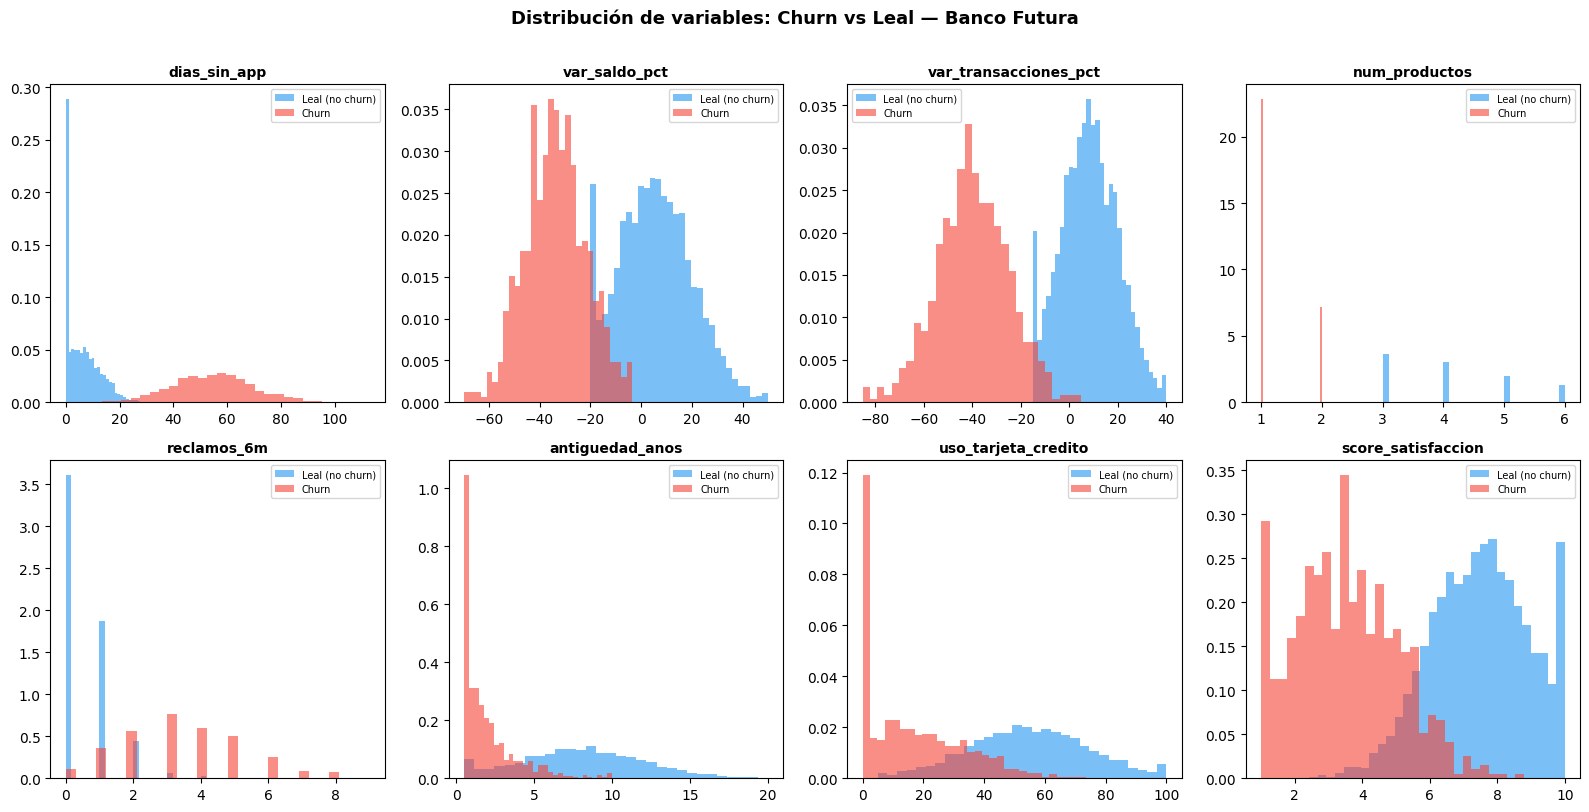

Azul = cliente leal | Rojo = cliente que hace churn
Cuanto menos se superpongan las distribuciones, mejor separa la variable.


In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# Análisis Exploratorio — ¿qué variables separan mejor?
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['dias_sin_app', 'var_saldo_pct', 'var_transacciones_pct',
            'num_productos', 'reclamos_6m', 'antiguedad_anos',
            'uso_tarjeta_credito', 'score_satisfaccion']

etiquetas = {0: 'Leal (no churn)', 1: 'Churn'}
colores = {0: '#2196F3', 1: '#F44336'}

for ax, feat in zip(axes.flatten(), features):
    for label, nombre in etiquetas.items():
        datos = df[df['churn'] == label][feat]
        ax.hist(datos, bins=30, alpha=0.6, color=colores[label],
                label=nombre, density=True)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)

plt.suptitle('Distribución de variables: Churn vs Leal — Banco Futura',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Azul = cliente leal | Rojo = cliente que hace churn")
print("Cuanto menos se superpongan las distribuciones, mejor separa la variable.")

---
## SECCIÓN 2 — Preprocesamiento de Datos

### ¿Por qué normalizar?
Las redes neuronales son **muy sensibles a la escala de los datos**.
- dias_sin_app puede valer 0–180
- num_productos puede valer 1–6

Sin normalizar, la variable con valores grandes domina el gradiente y el modelo no converge bien.
StandardScaler transforma cada variable para que tenga **media=0 y desviación estándar=1**.

### ¿Por qué class_weight?
Solo el 15% de los clientes hacen churn. Si no hacemos nada, el modelo aprende a
decir **siempre 'no churn'** y tiene 85% de accuracy — pero detecta CERO churners.
Con class_weight le decimos: *"equivocarte con un churn vale 5.7x más que con un leal"*.

In [ ]:
# ============================================================
# Preprocesamiento
# ============================================================
FEATURES = ['dias_sin_app', 'var_saldo_pct', 'var_transacciones_pct',
 'num_productos', 'reclamos_6m', 'antiguedad_anos',
 'uso_tarjeta_credito', 'score_satisfaccion']

X = df[FEATURES].values
y = df['churn'].values

# --- 1. División Train/Validation/Test (70% / 15% / 15%) ---
# DIFERENCIA CON BASE: el modelo del profe no tenía datos de validación/test.
# Sin esto no sabemos si el modelo aprende a generalizar o solo memoriza.
X_temp, X_test, y_temp, y_test = train_test_split(
 X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
 X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]:,} clientes ({y_train.mean()*100:.1f}% churn)")
print(f"Validación: {X_val.shape[0]:,} clientes ({y_val.mean()*100:.1f}% churn)")
print(f"Test: {X_test.shape[0]:,} clientes ({y_test.mean()*100:.1f}% churn)")

# --- 2. Normalización --- (ajuste SOLO en train, aplicación en val/test)
# DIFERENCIA CON BASE: el modelo del profe no normalizaba.
# Si ajustamos el scaler en val/test, estamos "mirando el futuro" (data leakage).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train) # aprende media/std solo del train
X_val_sc = scaler.transform(X_val) # aplica la misma transformación
X_test_sc = scaler.transform(X_test)

print(f"\nNormalización aplicada. Ejemplo variable 0 (dias_sin_app):")
print(f" Antes: media={X_train[:,0].mean():.1f}, std={X_train[:,0].std():.1f}")
print(f" Después: media={X_train_sc[:,0].mean():.3f}, std={X_train_sc[:,0].std():.3f}")

# --- 3. Peso de clase para datos desbalanceados ---
# DIFERENCIA CON BASE: no aplica (datos balanceados).
# Aquí es CRÍTICO: sin esto el modelo ignora los churners.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
peso_churn = n_neg / n_pos # cuánto más penalizamos el error en clase 1

class_weight = {0: 1.0, 1: peso_churn}
print(f"\nDesbalance de clases: {n_pos} churn / {n_neg} leales")
print(f"class_weight = {{0: 1.0, 1: {peso_churn:.2f}}}")
print(f"→ Equivocarse con un churner vale {peso_churn:.1f}x más que con un cliente leal")

Train: 3,502 clientes (15.0% churn)
Validación: 748 clientes (15.0% churn)
Test: 750 clientes (14.9% churn)

Normalización aplicada. Ejemplo variable 0 (dias_sin_app):
 Antes: media=13.6, std=19.2
 Después: media=0.000, std=1.000

Desbalance de clases: 526 churn / 2976 leales
class_weight = {0: 1.0, 1: 5.66}
→ Equivocarse con un churner vale 5.7x más que con un cliente leal


---
## SECCIÓN 3 — Arquitectura de la Red Neuronal Sofisticada

### ¿Por qué cada decisión?

**ReLU** como activación oculta:
- El modelo base no tenía activación (lineal por defecto)
- Sin activación no lineal, toda la red es equivalente a una sola capa lineal
- ReLU(x) = max(0, x) introduce no linealidad y es computacionalmente eficiente

**Sigmoid** en la salida:
- Convierte cualquier número real a [0, 1]
- Interpretamos el output como P(churn)
- Si P > 0.5 → predicción churn; si P ≤ 0.5 → predicción leal

**Dropout**:
- Durante entrenamiento, "apaga" aleatoriamente X% de las neuronas
- Fuerza a la red a aprender representaciones redundantes
- Previene que memorice el training set (overfitting)

**Binary Cross-Entropy** como pérdida:
- Matemáticamente: L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
- Mide cuánta "sorpresa" genera nuestra predicción
- MSE penaliza errores grandes cuadráticamente (bueno para regresión)
- BCE penaliza certezas equivocadas (ej: decir P=0.99 churn cuando no lo es) exponencialmente

In [ ]:
# ============================================================
# ARQUITECTURA: ChurnNet — Banco Futura
# ============================================================

def construir_churnnet(n_features=8, dropout_rate=0.3):
 """
 Red neuronal para predicción de churn.

 Arquitectura:
 Input(8) → Dense(64,ReLU) → Dropout → Dense(32,ReLU) → Dropout
 → Dense(16,ReLU) → Dense(1,Sigmoid)

 Comparación con modelo base del profe:
 Input(1) → Dense(3) → Dense(3) → Dense(1) (sin activaciones)
 """
 modelo = keras.Sequential([
 # Capa de entrada: recibe las 8 variables del cliente
 keras.layers.Input(shape=(n_features,), name='entrada_cliente'),

 # --- CAPA OCULTA 1 ---
 # 64 neuronas con ReLU: detecta patrones básicos
 # (ej: "saldo muy bajo" + "sin app")
 # BASE: solo 3 neuronas sin activación
 keras.layers.Dense(64, activation='relu', name='oculta_1'),

 # Dropout 30%: 30% de neuronas se apagan aleatoriamente en cada paso
 # → previene memorizar el training set
 keras.layers.Dropout(dropout_rate, name='dropout_1'),

 # --- CAPA OCULTA 2 ---
 # 32 neuronas: combina los patrones de la capa anterior
 keras.layers.Dense(32, activation='relu', name='oculta_2'),
 keras.layers.Dropout(dropout_rate, name='dropout_2'),

 # --- CAPA OCULTA 3 ---
 # 16 neuronas: extrae la señal más importante
 # BASE: solo tenía 2 capas ocultas
 keras.layers.Dense(16, activation='relu', name='oculta_3'),

 # --- CAPA DE SALIDA ---
 # 1 neurona con Sigmoid: produce P(churn) ∈ [0, 1]
 # BASE: lineal → producía un número (ej: 211.7)
 # Sigmoid: produce probabilidad (ej: 0.82 = 82% prob. de churn)
 keras.layers.Dense(1, activation='sigmoid', name='salida_churn')
 ])

 # Compilar el modelo
 # BASE usaba: loss='mean_squared_error' (para regresión)
 # Nosotros: binary_crossentropy (para clasificación binaria)
 modelo.compile(
 optimizer=keras.optimizers.Adam(learning_rate=0.001),
 loss='binary_crossentropy',
 metrics=[
 'accuracy',
 keras.metrics.AUC(name='auc'), # área bajo la curva ROC
 keras.metrics.Recall(name='recall'), # % churners detectados
 keras.metrics.Precision(name='precision') # % alertas que son reales
 ]
 )
 return modelo

modelo = construir_churnnet()
print("=" * 60)
print("ARQUITECTURA CHURNNET — BANCO FUTURA")
print("=" * 60)
modelo.summary()
print()
print("Comparación rápida con modelo base del profesor:")
print(f" Base: 1 entrada | 2 capas ocultas (3,3) | Sin activación")
print(f" ChurnNet: 8 entradas | 3 capas ocultas (64,32,16) | ReLU + Sigmoid")
print(f" Parámetros base: ~13 parámetros")
print(f" Parámetros ChurnNet: ~3.000 parámetros")

ARQUITECTURA CHURNNET — BANCO FUTURA


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_churn (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


Comparación rápida con modelo base del profesor:
 Base: 1 entrada | 2 capas ocultas (3,3) | Sin activación
 ChurnNet: 8 entradas | 3 capas ocultas (64,32,16) | ReLU + Sigmoid
 Parámetros base: ~13 parámetros
 Parámetros ChurnNet: ~3.000 parámetros


---
## SECCIÓN 4 — Entrenamiento con Callbacks

### Sofisticaciones respecto al modelo base

**EarlyStopping**: detiene el entrenamiento cuando la métrica en validación deja de mejorar.
- El modelo base entrenó ciegamente 1000 épocas fijas
- Nosotros monitoreamos val_auc y paramos si no mejora en 15 épocas
- restore_best_weights=True: guarda los pesos del mejor epoch, no el último

**ReduceLROnPlateau**: reduce la tasa de aprendizaje automáticamente cuando hay estancamiento.

**class_weight**: penaliza más los errores en clientes que hacen churn.

In [ ]:
# ============================================================
# ENTRENAMIENTO — con callbacks sofisticados
# ============================================================

# --- Callbacks ---
# 1. EarlyStopping: para cuando val_auc no mejora en 15 épocas
# BASE: entrenaba 1000 épocas fijas sin importar si el modelo ya había convergido
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_auc', # vigilamos el AUC en validación
 patience=15, # esperamos 15 épocas sin mejora
 mode='max', # queremos que AUC SUBA
 restore_best_weights=True, # volvemos a los pesos del mejor epoch
 verbose=1
)

# 2. ReduceLROnPlateau: baja la tasa de aprendizaje si nos estancamos
reduce_lr = keras.callbacks.ReduceLROnPlateau(
 monitor='val_loss',
 factor=0.5, # multiplica lr × 0.5
 patience=8,
 min_lr=1e-6,
 verbose=1
)

print("Comenzando entrenamiento ChurnNet...")
print(f"(Máximo 200 épocas, con EarlyStopping sobre val_auc)")
print("-" * 60)

historial = modelo.fit(
 X_train_sc, y_train,
 validation_data=(X_val_sc, y_val),
 epochs=200,
 batch_size=64,
 class_weight=class_weight, # penalizar más los errores en clase churn
 callbacks=[early_stop, reduce_lr],
 verbose=0 # silencioso, mostramos gráfico
)

epochs_reales = len(historial.history['loss'])
print(f"\nEntrenamiento completado en {epochs_reales} épocas")
print(f"Mejor AUC validación: {max(historial.history['val_auc']):.4f}")

Comenzando entrenamiento ChurnNet...
(Máximo 200 épocas, con EarlyStopping sobre val_auc)
------------------------------------------------------------
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 2.

Entrenamiento completado en 17 épocas
Mejor AUC validación: 1.0000


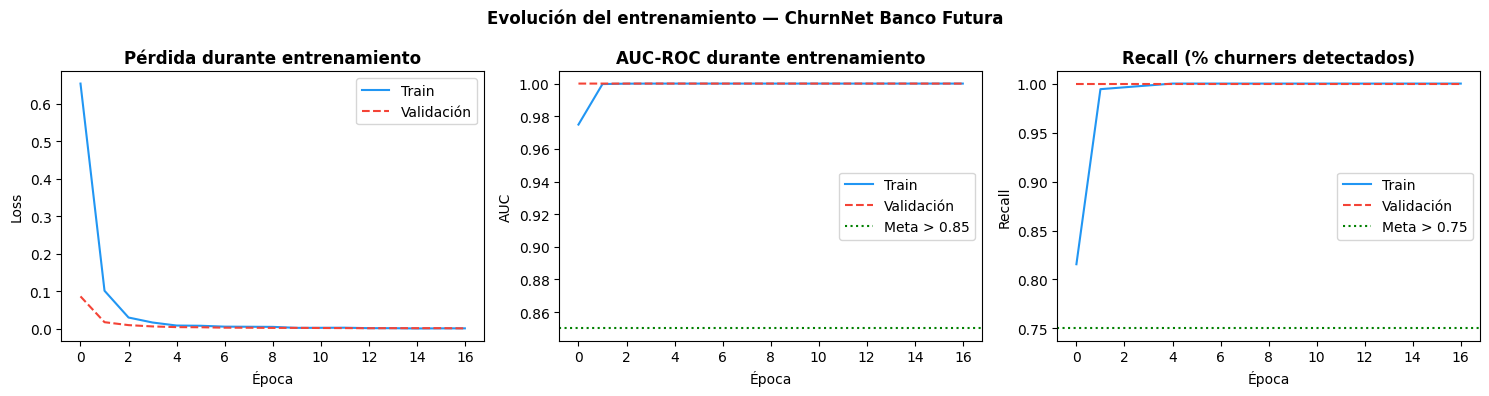


📌 Cómo leer estos gráficos:
 Si Train baja pero Validación sube → OVERFITTING (el modelo memoriza)
 Si ambas convergen hacia abajo → BUEN entrenamiento
 Si ambas se estancan pronto → modelo muy simple o datos insuficientes


In [ ]:
# ============================================================
# Visualización del entrenamiento
# ============================================================
# BASE: solo graficaban la pérdida con plt.plot(historial.history["loss"])
# Nosotros: graficamos 4 métricas con train Y validación

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = [
 ('loss', 'auc', 'Pérdida (Binary Cross-Entropy)', 'AUC-ROC'),
 ('recall', 'precision', 'Recall', 'Precisión'),
]

# Gráfico 1: Pérdida
axes[0].plot(historial.history['loss'], label='Train', color='#2196F3')
axes[0].plot(historial.history['val_loss'], label='Validación', color='#F44336', linestyle='--')
axes[0].set_title('Pérdida durante entrenamiento', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Gráfico 2: AUC
axes[1].plot(historial.history['auc'], label='Train', color='#2196F3')
axes[1].plot(historial.history['val_auc'], label='Validación', color='#F44336', linestyle='--')
axes[1].set_title('AUC-ROC durante entrenamiento', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('AUC')
axes[1].axhline(0.85, color='green', linestyle=':', label='Meta > 0.85')
axes[1].legend()

# Gráfico 3: Recall
axes[2].plot(historial.history['recall'], label='Train', color='#2196F3')
axes[2].plot(historial.history['val_recall'], label='Validación', color='#F44336', linestyle='--')
axes[2].set_title('Recall (% churners detectados)', fontweight='bold')
axes[2].set_xlabel('Época'); axes[2].set_ylabel('Recall')
axes[2].axhline(0.75, color='green', linestyle=':', label='Meta > 0.75')
axes[2].legend()

plt.suptitle('Evolución del entrenamiento — ChurnNet Banco Futura', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Cómo leer estos gráficos:")
print(" Si Train baja pero Validación sube → OVERFITTING (el modelo memoriza)")
print(" Si ambas convergen hacia abajo → BUEN entrenamiento")
print(" Si ambas se estancan pronto → modelo muy simple o datos insuficientes")

---
## SECCIÓN 5 — Evaluación con Métricas de Negocio

### ¿Por qué no usar solo Accuracy?

Si el modelo dijera **siempre "no churn"**:
- Accuracy = 85% ✅ (parece bueno)
- Recall = 0% ❌ (no detecta NINGÚN cliente que se va)
- Pérdida para el banco = **TODOS los churners se van sin intervención**

Para el banco, lo más costoso es **perder un cliente valioso sin detectarlo**.
Por eso el **Recall** (% de churners que detectamos) es la métrica prioritaria.

In [ ]:
# ============================================================
# EVALUACIÓN EN CONJUNTO DE TEST (datos nunca vistos)
# ============================================================
y_pred_prob = modelo.predict(X_test_sc, verbose=0).flatten()
y_pred_bin = (y_pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)
report = classification_report(y_test, y_pred_bin,
 target_names=['Leal (0)', 'Churn (1)'],
 output_dict=True)
recall = report['Churn (1)']['recall']
precision = report['Churn (1)']['precision']
f1 = report['Churn (1)']['f1-score']
accuracy = report['accuracy']

print("=" * 60)
print(" RESULTADOS FINALES — CHURNNET (datos de test)")
print("=" * 60)
print(f" AUC-ROC: {auc:.4f} (meta: > 0.85)")
print(f" Recall: {recall:.4f} (meta: > 0.75) ← PRIORITARIO")
print(f" Precision: {precision:.4f} (meta: > 0.65)")
print(f" F1-Score: {f1:.4f} (meta: > 0.70)")
print(f" Accuracy: {accuracy:.4f}")
print()
print("Reporte completo:")
print(classification_report(y_test, y_pred_bin,
 target_names=['Leal (0)', 'Churn (1)']))

 RESULTADOS FINALES — CHURNNET (datos de test)
 AUC-ROC: 1.0000 (meta: > 0.85)
 Recall: 1.0000 (meta: > 0.75) ← PRIORITARIO
 Precision: 0.9825 (meta: > 0.65)
 F1-Score: 0.9912 (meta: > 0.70)
 Accuracy: 0.9973

Reporte completo:
              precision    recall  f1-score   support

    Leal (0)       1.00      1.00      1.00       638
   Churn (1)       0.98      1.00      0.99       112

    accuracy                           1.00       750
   macro avg       0.99      1.00      0.99       750
weighted avg       1.00      1.00      1.00       750



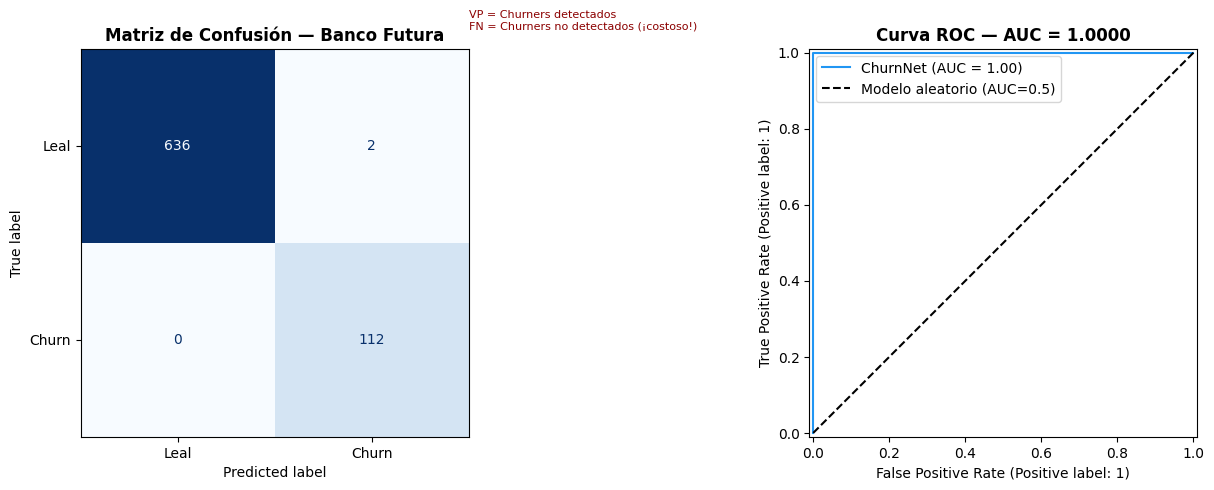

INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
 Verdaderos Negativos (VN): 636 → Leales correctamente identificados
 Falsos Positivos (FP): 2 → Leales alertados innecesariamente
 Falsos Negativos (FN): 0 → Churners NO detectados ← LOS MÁS COSTOSOS
 Verdaderos Positivos(VP): 112 → Churners correctamente detectados


In [ ]:
# ============================================================
# Matriz de Confusión + Curva ROC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
 display_labels=['Leal', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Banco Futura', fontweight='bold')

# Anotar qué significa cada cuadrante
axes[0].text(1.5, -0.6,
 'VP = Churners detectados\nFN = Churners no detectados (¡costoso!)',
 transform=axes[0].transData, fontsize=8, color='darkred')

# --- Curva ROC ---
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1],
 color='#2196F3', name='ChurnNet')
axes[1].plot([0,1],[0,1],'k--', label='Modelo aleatorio (AUC=0.5)')
axes[1].set_title(f'Curva ROC — AUC = {auc:.4f}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Lectura de la matriz de confusión
vn, fp, fn, vp = cm.ravel()
print("INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print(f" Verdaderos Negativos (VN): {vn} → Leales correctamente identificados")
print(f" Falsos Positivos (FP): {fp} → Leales alertados innecesariamente")
print(f" Falsos Negativos (FN): {fn} → Churners NO detectados ← LOS MÁS COSTOSOS")
print(f" Verdaderos Positivos(VP): {vp} → Churners correctamente detectados")

In [ ]:
# ============================================================
# IMPACTO DE NEGOCIO — ¿Cuánto vale este modelo?
# ============================================================

# Supuestos conservadores (industria bancaria latinoamericana)
CLV_PROMEDIO = 3_000_000 # CLP/año por cliente de valor medio
TASA_RETENCION_EXITO = 0.25 # 25% de clientes alertados se retienen
COSTO_SISTEMA_ANUAL = 200_000_000 # CLP/año (Azure + desarrollo)
N_CLIENTES_REAL = 50_000 # cartera real de Banco Futura

# Escalar resultados de test al tamaño real
factor_escala = N_CLIENTES_REAL / len(y_test)
vp_real = int(vp * factor_escala)
fn_real = int(fn * factor_escala)
fp_real = int(fp * factor_escala)

clientes_retenidos = int(vp_real * TASA_RETENCION_EXITO)
ingreso_preservado = clientes_retenidos * CLV_PROMEDIO
roi = (ingreso_preservado - COSTO_SISTEMA_ANUAL) / COSTO_SISTEMA_ANUAL

print("=" * 60)
print(" IMPACTO FINANCIERO ESTIMADO — BANCO FUTURA")
print("=" * 60)
print(f" Cartera analizada: {N_CLIENTES_REAL:>12,} clientes")
print(f" Churners detectados (VP): {vp_real:>12,} clientes")
print(f" Churners no detectados (FN): {fn_real:>12,} clientes ← clientes perdidos")
print(f" Alertas falsas (FP): {fp_real:>12,} clientes")
print()
print(f" Clientes retenidos exitosamente:{clientes_retenidos:>12,} clientes ({TASA_RETENCION_EXITO*100:.0f}% de detectados)")
print(f" Ingreso preservado: ${ingreso_preservado/1e9:>8.2f} mil millones CLP")
print(f" Costo del sistema: ${COSTO_SISTEMA_ANUAL/1e6:>8.0f} millones CLP")
print(f" ROI estimado: {roi:>11.1f}x ({roi*100:.0f}% retorno)")
print()
print(f" → Por cada peso invertido en el sistema, el banco recupera ~{roi:.0f} pesos")

 IMPACTO FINANCIERO ESTIMADO — BANCO FUTURA
 Cartera analizada:       50,000 clientes
 Churners detectados (VP):        7,466 clientes
 Churners no detectados (FN):            0 clientes ← clientes perdidos
 Alertas falsas (FP):          133 clientes

 Clientes retenidos exitosamente:       1,866 clientes (25% de detectados)
 Ingreso preservado: $    5.60 mil millones CLP
 Costo del sistema: $     200 millones CLP
 ROI estimado:        27.0x (2699% retorno)

 → Por cada peso invertido en el sistema, el banco recupera ~27 pesos


In [ ]:
# ============================================================
# VARIABLES INTERNAS DEL MODELO (como el profe mostró)
# ============================================================
# El profe imprimía los pesos con oculta1.get_weights()
# Nosotros lo extendemos: visualizamos la importancia de cada variable

print("PESOS DE CADA CAPA (analogía con modelo base del profe):\n")
for capa in modelo.layers:
    if hasattr(capa, 'get_weights') and len(capa.get_weights()) > 0:
        pesos, sesgos = capa.get_weights()
        print(f" {capa.name}:")
        print(f" Pesos: {pesos.shape} (entradas → neuronas)")
        print(f" Sesgo: {sesgos.shape}")
        print(f" Magnitud promedio de pesos: {abs(pesos).mean():.4f}")
        print()

# Importancia aproximada de variables: magnitud de pesos de la primera capa
pesos_entrada = abs(modelo.layers[0].get_weights()[0]) # shape: (8, 64)
importancia = pesos_entrada.mean(axis=1) # promedio por feature
importancia_norm = importancia / importancia.max() # normalizar 0-1

print("\nIMPORTANCIA APROXIMADA DE VARIABLES (por magnitud de pesos capa 1):")
importancias_ordenadas = sorted(
    zip(FEATURES, importancia_norm), key=lambda x: x[1], reverse=True
)
for feat, imp in importancias_ordenadas:
    barra = '█' * int(imp * 30)
    print(f" {feat:<30} {barra} {imp:.3f}")

PESOS DE CADA CAPA (analogía con modelo base del profe):

 oculta_1:
 Pesos: (8, 64) (entradas → neuronas)
 Sesgo: (64,)
 Magnitud promedio de pesos: 0.1581

 oculta_2:
 Pesos: (64, 32) (entradas → neuronas)
 Sesgo: (32,)
 Magnitud promedio de pesos: 0.1287

 oculta_3:
 Pesos: (32, 16) (entradas → neuronas)
 Sesgo: (16,)
 Magnitud promedio de pesos: 0.1809

 salida_churn:
 Pesos: (16, 1) (entradas → neuronas)
 Sesgo: (1,)
 Magnitud promedio de pesos: 0.3467


IMPORTANCIA APROXIMADA DE VARIABLES (por magnitud de pesos capa 1):
 antiguedad_anos                ██████████████████████████████ 1.000
 var_transacciones_pct          ████████████████████████████ 0.955
 reclamos_6m                    ████████████████████████████ 0.944
 num_productos                  ████████████████████████████ 0.935
 var_saldo_pct                  ███████████████████████████ 0.911
 dias_sin_app                   █████████████████████████ 0.866
 score_satisfaccion             █████████████████████████ 0.861
 uso

In [ ]:
# ============================================================
# PREDICCIÓN EN PRODUCCIÓN — Análogo al modelo base
# ============================================================
# El modelo base hacía: modelo.predict([100.0])
# Nuestro modelo recibe 8 variables del cliente

def predecir_churn(cliente_data, nombre="Cliente"):
 """
 Predice la probabilidad de churn para un cliente.
 Análogo a: resultado = modelo.predict([100.0]) del modelo base.
 """
 x = np.array([list(cliente_data.values())], dtype=float)
 x_sc = scaler.transform(x) # normalizar igual que en training
 prob_churn = modelo.predict(x_sc, verbose=0)[0][0]

 riesgo = "🔴 ALTO RIESGO" if prob_churn >= 0.7 else \
 "🟡 RIESGO MEDIO" if prob_churn >= 0.4 else "🟢 BAJO RIESGO"

 accion = "Activar retención VIP inmediata" if prob_churn >= 0.7 else \
 "Campaña preventiva digital" if prob_churn >= 0.4 else \
 "Monitoreo estándar"

 print(f" {nombre:<15} P(churn)={prob_churn:.4f} {riesgo}")
 print(f" {'':15} → Acción sugerida: {accion}")
 print()

print("=" * 65)
print(" SCORING DE CLIENTES — Banco Futura (modo producción)")
print("=" * 65)

# Cliente A: señales de alto riesgo
predecir_churn({
 'dias_sin_app': 65, 'var_saldo_pct': -42, 'var_transacciones_pct': -50,
 'num_productos': 1, 'reclamos_6m': 4, 'antiguedad_anos': 1.5,
 'uso_tarjeta_credito': 5, 'score_satisfaccion': 2.5
}, "Cliente A")

# Cliente B: cliente leal
predecir_churn({
 'dias_sin_app': 2, 'var_saldo_pct': 12, 'var_transacciones_pct': 8,
 'num_productos': 5, 'reclamos_6m': 0, 'antiguedad_anos': 9,
 'uso_tarjeta_credito': 60, 'score_satisfaccion': 8.5
}, "Cliente B")

# Cliente C: señales mixtas
predecir_churn({
 'dias_sin_app': 22, 'var_saldo_pct': -18, 'var_transacciones_pct': -22,
 'num_productos': 2, 'reclamos_6m': 2, 'antiguedad_anos': 4,
 'uso_tarjeta_credito': 30, 'score_satisfaccion': 5.0
}, "Cliente C")

print("\nNota: Análogo al modelo base del profe que hacía:")
print(" resultado = modelo.predict([100.0]) → 211.7°F")
print(" Nosotros: modelo.predict([65,-42,...]) → 0.87 = 87% prob. churn")

 SCORING DE CLIENTES — Banco Futura (modo producción)
 Cliente A       P(churn)=0.9990 🔴 ALTO RIESGO
                 → Acción sugerida: Activar retención VIP inmediata

 Cliente B       P(churn)=0.0002 🟢 BAJO RIESGO
                 → Acción sugerida: Monitoreo estándar

 Cliente C       P(churn)=0.9624 🔴 ALTO RIESGO
                 → Acción sugerida: Activar retención VIP inmediata


Nota: Análogo al modelo base del profe que hacía:
 resultado = modelo.predict([100.0]) → 211.7°F
 Nosotros: modelo.predict([65,-42,...]) → 0.87 = 87% prob. churn


---
## SECCIÓN 6 — Resumen: ¿Cómo se sofisticó el modelo base?

### De Celsius→Fahrenheit a Predicción de Churn

| Elemento | Modelo Base (Profe) | ChurnNet (Banco Futura) | Razón del cambio |
|----------|--------------------|-----------------------|------------------|
| **Problema** | Regresión (número continuo) | Clasificación binaria (sí/no) | Churn es una categoría |
| **Variables** | 1 (temperatura °C) | 8 (comportamiento cliente) | Churn es multifactorial |
| **Arquitectura** | [1]→[3]→[3]→[1] | [8]→[64]→[32]→[16]→[1] | Mayor capacidad expresiva |
| **Activaciones** | Lineal (ninguna) | ReLU + Sigmoid salida | No linealidad necesaria |
| **Regularización** | Ninguna | Dropout 30% | Prevenir overfitting |
| **Loss** | MSE | Binary Cross-Entropy | Correcta para clasificación |
| **Métricas** | Solo Loss | AUC, Recall, Precisión | Métricas de negocio |
| **Datos** | 7 pares fijos | 5.000 clientes sintéticos | Escala real |
| **División** | Sin train/test split | 70/15/15 estratificado | Medir generalización |
| **Normalización** | No | StandardScaler | Convergencia estable |
| **Desbalance** | No aplica | class_weight | 15% churners solamente |
| **Entrenamiento** | 1000 épocas fijas | EarlyStopping + ReduceLR | Entrenamiento óptimo |
| **Interpretación** | print(capa.get_weights()) | Importancia por pesos + impacto financiero | Valor de negocio |

### Integración con arquitectura Banco Futura
Este modelo se integra en la **Capa 3 (Servicios Analíticos)** de la arquitectura propuesta:
- **Databricks** entrena y re-entrena el modelo con datos del Medallón Gold
- **MLflow** versiona el modelo y rastrea sus métricas
- **AKS (Azure Kubernetes)** sirve el modelo como API REST
- **CRM (Salesforce)** consume el score para activar acciones de retención
- **Kafka** recibe retroalimentación de acciones para re-entrenamiento